<div style="text-align: right; font-weight: bold;">
東京工科大学コンピュータサイエンス学部<br>
福西広晃
</div>

----

<span style="font-size: 250%; color: black;">1.4 回帰分析とデータ可視化</span>

----

# 重回帰分析の解説

## 重回帰分析とは

**重回帰分析**とは、**複数のデータを使って、ある数値を予測する方法**である。

例えば、住宅の価格を予測する場合を考える。

住宅の価格は、1つの要因だけではなく、

- 部屋の広さ
- 駅からの距離
- 築年数

など、複数の要因によって変化すると考えられる。

重回帰分析では、**「広さ80㎡、駅から徒歩10分、築10年の住宅はいくらくらいか」**

といった住宅価格の予測ができる。

---

## 説明変数と目的変数

重回帰分析では、データを**説明変数**と**目的変数**に分ける。

### 説明変数

予測するために使用するデータを**説明変数**という。

住宅価格を予測する場合、

- 部屋の広さ
- 駅からの距離
- 築年数

などが説明変数となる。

### 目的変数

予測したいデータを**目的変数**という。

今回の場合は、**住宅価格**が目的変数となる。

したがって、

**説明変数：部屋の広さ・駅からの距離・築年数**  
**目的変数：住宅価格**

となる。

---

## 重回帰分析の考え方

重回帰分析では、複数の説明変数と目的変数の関係を次のような式で表す。

$$
y = a_1x_1 + a_2x_2 + a_3x_3 + b
$$

住宅価格の例では、次のように考えることができる。

- $x_1$：部屋の広さ
- $x_2$：駅からの距離
- $x_3$：築年数
- $y$：住宅価格
- $b$：切片（定数項）

Pythonを使うと、実際のデータから $a_1$、$a_2$、$a_3$、$b$ の値を求めることができる。

----

# ツールのインストトール

In [ ]:
!pip  -q install matplotlib
!pip  -q install matplotlib_fontja
!pip  -q install statsmodels
!pip  -q install pandas

# データ準備
- **勉強時間・睡眠時間・出席率からテスト点数は何点になるか** という関係を重回帰分析で学習する
- **説明変数 X**：勉強時間、睡眠時間、出席率
- **目的変数 y**：テスト点数

たとえば、
「勉強時間5時間、睡眠時間7時間、出席率90%の学生は、テストで何点くらい取るか？」
を予測する、という課題にできます。

In [1]:
import pandas as pd

# サンプルデータを作成
data = {
    "勉強時間（時間）": [2, 3, 4, 5, 6, 7, 3, 5, 6, 8, 1, 4, 5, 7, 8, 2, 6, 4, 7, 9],
    "睡眠時間（時間）": [6, 7, 6, 8, 7, 8, 5, 6, 8, 7, 6, 7, 8, 6, 8, 7, 6, 8, 7, 8],
    "出席率（%）": [70, 80, 85, 90, 95, 95, 75, 85, 90, 100, 65, 80, 90, 85, 95, 70, 100, 75, 90, 100],
    "テスト点数（点）": [50, 60, 65, 78, 82, 90, 55, 70, 85, 92, 42, 63, 75, 80, 94, 53, 86, 68, 88, 98]
}

# データフレームに変換
df = pd.DataFrame(data)

# データフレームを表示
display(df)

ModuleNotFoundError: No module named 'pandas'

# データ可視化

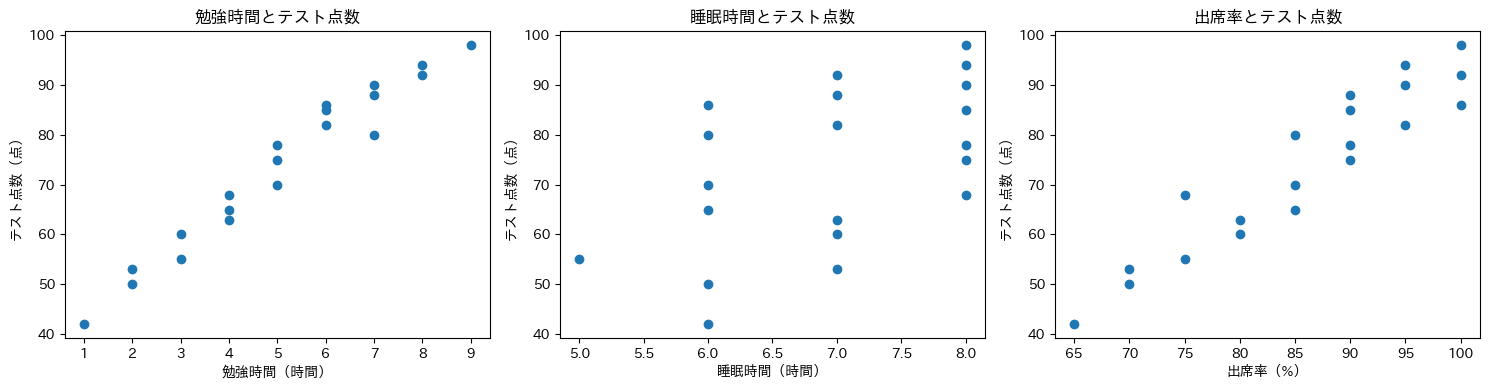

In [15]:
import matplotlib.pyplot as plt
import matplotlib_fontja

# グラフを横に3つ並べる
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 勉強時間とテスト点数
axes[0].scatter(df["勉強時間（時間）"], df["テスト点数（点）"])
axes[0].set_xlabel("勉強時間（時間）")
axes[0].set_ylabel("テスト点数（点）")
axes[0].set_title("勉強時間とテスト点数")

# 睡眠時間とテスト点数
axes[1].scatter(df["睡眠時間（時間）"], df["テスト点数（点）"])
axes[1].set_xlabel("睡眠時間（時間）")
axes[1].set_ylabel("テスト点数（点）")
axes[1].set_title("睡眠時間とテスト点数")

# 出席率とテスト点数
axes[2].scatter(df["出席率（%）"], df["テスト点数（点）"])
axes[2].set_xlabel("出席率（%）")
axes[2].set_ylabel("テスト点数（点）")
axes[2].set_title("出席率とテスト点数")

# グラフの間隔を自動調整
plt.tight_layout()

plt.show()

# 重回帰モデルの作成
- 説明変数 X：勉強時間、睡眠時間、出席率
- 目的変数 y：テスト点数

In [16]:
import statsmodels.api as sm

# 説明変数
X = df[["勉強時間（時間）", "睡眠時間（時間）", "出席率（%）"]]

# 目的変数
y = df["テスト点数（点）"]

# 回帰式に切片を追加
X = sm.add_constant(X)

# 重回帰モデルをデータから学習
model = sm.OLS(y, X)

# 分析を実行
result = model.fit()

# 分析結果を表示する
**回帰係数の見方**  
- **回帰係数がプラス**  → 説明変数が大きいほど、目的変数も大きくなる傾向がある。
- **回帰係数がマイナス** → 説明変数が大きいほど、目的変数は小さくなる傾向がある。
- **p値** → 各説明変数と目的変数の関係が統計的に有意かを判断するための値（一般に**0.05未満**なら有意）

In [17]:
import pandas as pd

# 回帰係数とp値を表にまとめる
result_table = pd.DataFrame({"回帰係数": result.params, "p値": result.pvalues})

# 小数第3位まで表示
result_table.round(3)

,回帰係数,p値
const,-4.916,0.527
勉強時間（時間）,4.693,0.000
睡眠時間（時間）,2.139,0.002
出席率（%）,0.464,0.000


- **勉強時間**  
  - 勉強時間の回帰係数は **4.693**、p値は **0.001未満** であった。したがって、睡眠時間と出席率が同じであるとした場合、**勉強時間が1時間長い学生ほど、テスト点数が平均して約4.7点高い**という関係がある。また、p値が0.05未満であるため、**統計的に有意な正の関係**が認められた。

- **睡眠時間**  
  - 睡眠時間の回帰係数は **2.139**、p値は **0.002** であった。したがって、勉強時間と出席率が同じであるとした場合、**睡眠時間が1時間長い学生ほど、テスト点数が平均して約2.1点高い**という関係がある。また、p値が0.05未満であるため、**統計的に有意な正の関係**が認められた。

- **出席率**  
  - 出席率の回帰係数は **0.464**、p値は **0.001未満** であった。したがって、勉強時間と睡眠時間が同じであるとした場合、**出席率が1ポイント（例：80%から81%）高い学生ほど、テスト点数が平均して約0.46点高い**という関係がある。また、p値が0.05未満であるため、**統計的に有意な正の関係**が認められた。

# 重回帰モデルがデータをどの程度説明できるか確認
**決定係数（R²）**は、重回帰モデルが目的変数のばらつきをどの程度説明できているかを表す値である。

- 1に近いほど、モデルの説明力が高い
- 0に近いほど、モデルの説明力が低い

例えば、R²が `0.80` の場合、モデルによって目的変数のばらつきの約80%を説明できていると考える。

決定係数(R²) = 0.986


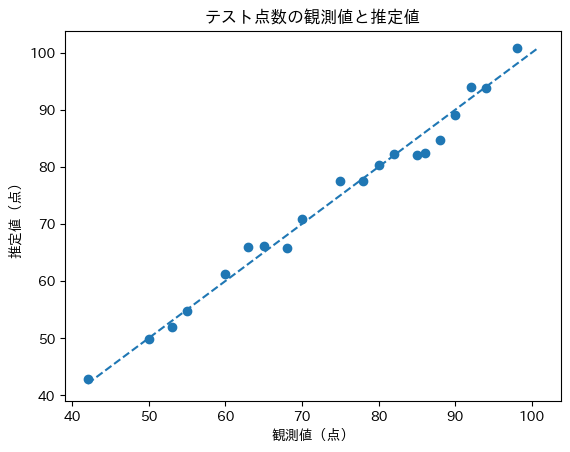

In [18]:
import matplotlib.pyplot as plt
import matplotlib_fontja

# 決定係数（R²）を表示
print("決定係数(R²) =", round(result.rsquared, 3))

# 重回帰モデルからテスト点数の推定値を取得
y_fitted = result.fittedvalues

# 観測値と推定値の散布図
plt.scatter(y, y_fitted)

# 観測値と推定値が一致する直線
min_value = min(y.min(), y_fitted.min())
max_value = max(y.max(), y_fitted.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("観測値（点）")
plt.ylabel("推定値（点）")
plt.title("テスト点数の観測値と推定値")

plt.show()

----

# 練習問題

ある飲食店では、**1日の売上**にどのような要因が関係しているかを調べるため、20日間のデータを収集した。

データには、次の項目が含まれている。

- **広告費（千円）**：その日に使用した広告費
- **気温（℃）**：その日の平均気温
- **来店客数（人）**：その日の来店客数
- **売上（万円）**：その日の売上

このデータを用いて、**売上を目的変数**とした重回帰分析を行いなさい。

**手順**
- 広告費、気温、来店客数と売上の関係を**散布図**で確認しましょう。
- 次のように説明変数と目的変数を設定し、**重回帰分析**を行いましょう。
  - 説明変数：広告費、気温、来店客数
  - 目的変数：売上
- 各説明変数の**回帰係数**と**p値**を確認しましょう。
  - 各説明変数の回帰係数について、どのような意味を持つか説明しましょう。
  - p値が0.05未満の説明変数を確認し、売上と統計的に有意な関係がある説明変数を確認しましよう。
- **決定係数(R²)** を求め、データをどの程度説明できるかを確認しましょう。
  - 売上の**観測値と推定値の散布図**を作成しましょう。

**データの準備**

In [19]:
import pandas as pd

# サンプルデータ
data = {
    "広告費（千円）": [5, 8, 3, 10, 6, 12, 4, 9, 7, 11, 2, 13, 5, 8, 10, 6, 14, 3, 9, 7],
    "気温（℃）": [18, 20, 17, 22, 19, 25, 16, 23, 21, 24, 15, 27, 18, 20, 26, 19, 28, 17, 23, 21],
    "来店客数（人）": [42, 50, 35, 65, 48, 72, 38, 60, 55, 68, 30, 78, 45, 53, 70, 49, 82, 36, 63, 54],
    "売上（万円）": [18, 23, 15, 31, 21, 35, 17, 29, 26, 33, 13, 38, 20, 25, 34, 22, 40, 16, 30, 25]
}

# データフレームに変換
df = pd.DataFrame(data)

# データを表示
display(df)

,広告費（千円）,気温（℃）,来店客数（人）,売上（万円）
0,5,18,42,18
1,8,20,50,23
2,3,17,35,15
3,10,22,65,31
4,6,19,48,21
5,12,25,72,35
6,4,16,38,17
7,9,23,60,29
8,7,21,55,26
9,11,24,68,33


## 広告費、気温、来店客数と売上の関係を散布図で確認しましょう。

## 次のように説明変数と目的変数を設定し、重回帰分析を行いましょう。
- 説明変数：広告費、気温、来店客数
- 目的変数：売上

## 各説明変数の回帰係数とp値を確認しましょう。
- 各説明変数の回帰係数について、どのような意味を持つか説明しましょう。
- p値が0.05未満の説明変数を確認し、売上と統計的に有意な関係がある説明変数を確認しましよう。

## 決定係数(R²) を求め、データをどの程度説明できるかを確認しましょう。
- 売上の観測値と推定値の散布図を作成しましょう。

----
----
----
----
----
----
----
----
----
----

# 練習問題の解答例

## 広告費、気温、来店客数と売上の関係を散布図で確認しましょう。

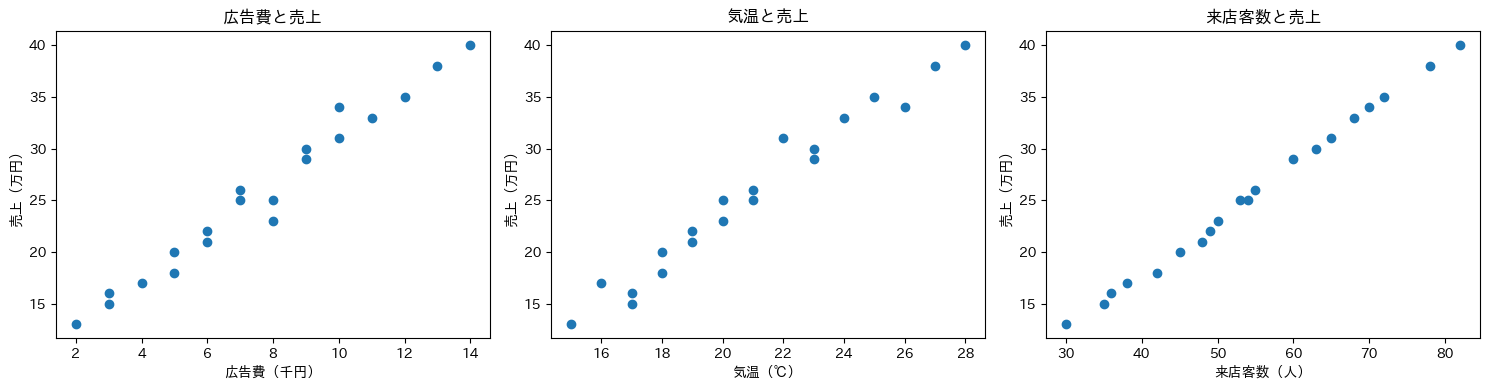

In [20]:
import matplotlib.pyplot as plt
import matplotlib_fontja

# グラフを横に3つ並べる
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 広告費と売上
axes[0].scatter(df["広告費（千円）"], df["売上（万円）"])
axes[0].set_xlabel("広告費（千円）")
axes[0].set_ylabel("売上（万円）")
axes[0].set_title("広告費と売上")

# 気温と売上
axes[1].scatter(df["気温（℃）"], df["売上（万円）"])
axes[1].set_xlabel("気温（℃）")
axes[1].set_ylabel("売上（万円）")
axes[1].set_title("気温と売上")

# 来店客数と売上
axes[2].scatter(df["来店客数（人）"], df["売上（万円）"])
axes[2].set_xlabel("来店客数（人）")
axes[2].set_ylabel("売上（万円）")
axes[2].set_title("来店客数と売上")

# グラフの間隔を自動調整
plt.tight_layout()

plt.show()

## 次のように説明変数と目的変数を設定し、重回帰分析を行いましょう。
- 説明変数：広告費、気温、来店客数
- 目的変数：売上

In [21]:
import statsmodels.api as sm

# 説明変数
X = df[["広告費（千円）","気温（℃）","来店客数（人）"]]

# 目的変数
y = df["売上（万円）"]

# 切片を追加
X = sm.add_constant(X)

# 重回帰モデルをデータから学習
model = sm.OLS(y, X)

# 分析を実行
result = model.fit()

## 各説明変数の回帰係数とp値を確認しましょう。
- 各説明変数の回帰係数について、どのような意味を持つか説明しましょう。
- p値が0.05未満の説明変数を確認し、売上と統計的に有意な関係がある説明変数を確認しましよう。

In [22]:
# 回帰係数とp値を表にまとめる
result_table = pd.DataFrame({"回帰係数": result.params, "p値": result.pvalues})

# 小数第3位まで表示
result_table.round(3)

,回帰係数,p値
const,-4.529,0.006
広告費（千円）,0.082,0.681
気温（℃）,0.165,0.342
来店客数（人）,0.476,0.000


**広告費**  
広告費の回帰係数は **0.082** である。他の説明変数が同じであるとした場合、広告費が1千円多いと、売上が平均して約0.082万円高いという関係を表している。
ただし、p値は **0.681** であり、0.05以上であるため、**広告費と売上に統計的に有意な関係があるとはいえない**。

**気温**  
気温の回帰係数は **0.165** である。他の説明変数が同じであるとした場合、気温が1℃高いと、売上が平均して約0.165万円高いという関係を表している。
ただし、p値は **0.342** であり、0.05以上であるため、**気温と売上に統計的に有意な関係があるとはいえない**。

**来店客数**  
来店客数の回帰係数は **0.476** である。他の説明変数が同じであるとした場合、来店客数が1人多いと、売上が平均して約0.476万円高いという関係を表している。
また、p値は **0.001未満** であり、0.05未満であるため、**来店客数と売上には統計的に有意な正の関係がある**。

## 決定係数(R²) を求め、データをどの程度説明できるかを確認しましょう。
- 売上の観測値と推定値の散布図を作成しましょう。

決定係数(R²) = 0.997


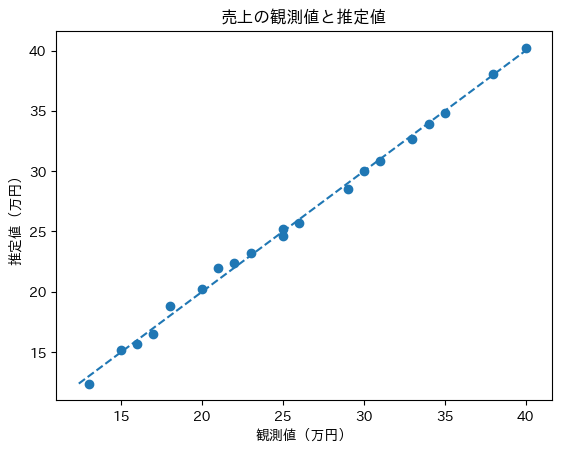

In [23]:
import matplotlib.pyplot as plt
import matplotlib_fontja

# 決定係数（R²）を表示
print("決定係数(R²) =", round(result.rsquared, 3))

# 重回帰モデルから売上の推定値を取得
y_fitted = result.fittedvalues

# 観測値と推定値の散布図
plt.scatter(y, y_fitted)

# 観測値と推定値が一致する直線
min_value = min(y.min(), y_fitted.min())
max_value = max(y.max(), y_fitted.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

# グラフのタイトルと軸ラベル
plt.xlabel("観測値（万円）")
plt.ylabel("推定値（万円）")
plt.title("売上の観測値と推定値")

plt.show()